# CartPole-v1 IQ-Learn Workflow

This notebook documents the current end-to-end workflow for `CartPole-v1 + IQ-Learn`:

1. Ensure shared expert artifacts are available locally.
2. Inspect expert dataset quality.
3. Optionally run IQ-Learn training.
4. Aggregate logs and visualize evaluation results.

The default notebook path is non-destructive and does **not** rerun training. Set `RUN_TRAINING = True` only when you intentionally want to regenerate IQ-Learn logs/checkpoints.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

ENV_ID = "CartPole-v1"
ALGORITHM = "iqlearn"
SEEDS = [0, 1, 2]
TRAJECTORY_SIZES = [1, 5, 10, 20]
RUN_TRAINING = False

print(f"project root: {PROJECT_ROOT}")
BASE_ENV = {**os.environ, "MPLBACKEND": "Agg"}
print(f"run training: {RUN_TRAINING}")

project root: /Users/zitian/imitation-learning-project
run training: False


/var/folders/yp/cb8wz__516l5fbzrnmfzddlh0000gn/T/ipykernel_98490/3065321308.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Ensure shared artifacts are available

Expert policies and expert datasets are shared through Google Drive and are not committed to Git. If the files are already present locally, this section does nothing. Otherwise it uses `rclone` to download the shared CartPole artifact bundle, verifies the checksum, and extracts it into the repository root.

In [2]:
expected_expert_paths = [
    PROJECT_ROOT / "models" / "expert" / ENV_ID / f"expert_seed_{seed}.zip"
    for seed in SEEDS
]
expected_dataset_paths = [
    PROJECT_ROOT / "data" / "expert" / ENV_ID / f"traj_{k}" / f"seed_{seed}.npz"
    for k in TRAJECTORY_SIZES
    for seed in SEEDS
]
missing = [path for path in expected_expert_paths + expected_dataset_paths if not path.exists()]

if missing:
    print(f"missing {len(missing)} artifact files; downloading from Google Drive")
    subprocess.run(
        [
            "rclone",
            "copy",
            "gdrive:imitation-learning-project-artifacts/CartPole-v1/cartpole_expert_artifacts.tar.gz",
            str(PROJECT_ROOT),
        ],
        check=True,
    )
    subprocess.run(
        [
            "rclone",
            "copy",
            "gdrive:imitation-learning-project-artifacts/CartPole-v1/cartpole_expert_artifacts.sha256",
            str(PROJECT_ROOT),
        ],
        check=True,
    )
    subprocess.run(["shasum", "-a", "256", "-c", "cartpole_expert_artifacts.sha256"], cwd=PROJECT_ROOT, check=True)
    subprocess.run(["tar", "-xzf", "cartpole_expert_artifacts.tar.gz"], cwd=PROJECT_ROOT, check=True)
else:
    print("all shared expert artifacts are already available locally")

print("expert files:")
for path in expected_expert_paths:
    print(" ", path.relative_to(PROJECT_ROOT), path.exists())

all shared expert artifacts are already available locally
expert files:
  models/expert/CartPole-v1/expert_seed_0.zip True
  models/expert/CartPole-v1/expert_seed_1.zip True
  models/expert/CartPole-v1/expert_seed_2.zip True


## 2. Inspect expert dataset quality

For `CartPole-v1`, a strong expert reaches the environment time limit of 500 steps. Therefore a high-quality dataset should have roughly:

- `traj_1`: 500 transitions
- `traj_5`: 2500 transitions
- `traj_10`: 5000 transitions
- `traj_20`: 10000 transitions

Actions should be discrete integers in `{0, 1}`.

In [3]:
from scripts.inspect_dataset import inspect_dataset, summary_to_frame

quality_frames = []
for k in TRAJECTORY_SIZES:
    for seed in SEEDS:
        dataset_path = PROJECT_ROOT / "data" / "expert" / ENV_ID / f"traj_{k}" / f"seed_{seed}.npz"
        summary = inspect_dataset(dataset_path, env_id=ENV_ID)
        frame = summary_to_frame(summary)
        frame.insert(0, "trajectory_size", k)
        frame.insert(1, "seed", seed)
        quality_frames.append(frame)

dataset_quality = pd.concat(quality_frames, ignore_index=True)
selected_columns = [
    "trajectory_size",
    "seed",
    "episodes",
    "transitions",
    "return_mean",
    "return_std",
    "length_mean",
    "action_dtype",
    "unique_actions",
    "check_cartpole_actions_are_0_or_1",
    "check_cartpole_full_length_expert",
]
dataset_quality[selected_columns]

,trajectory_size,seed,episodes,transitions,return_mean,return_std,length_mean,action_dtype,unique_actions,check_cartpole_actions_are_0_or_1,check_cartpole_full_length_expert
0,1,0,1,500,500.0,0.0,500.0,int64,"[0, 1]",True,True
1,1,1,1,500,500.0,0.0,500.0,int64,"[0, 1]",True,True
2,1,2,1,500,500.0,0.0,500.0,int64,"[0, 1]",True,True
3,5,0,5,2500,500.0,0.0,500.0,int64,"[0, 1]",True,True
4,5,1,5,2500,500.0,0.0,500.0,int64,"[0, 1]",True,True
5,5,2,5,2500,500.0,0.0,500.0,int64,"[0, 1]",True,True
6,10,0,10,5000,500.0,0.0,500.0,int64,"[0, 1]",True,True
7,10,1,10,5000,500.0,0.0,500.0,int64,"[0, 1]",True,True
8,10,2,10,5000,500.0,0.0,500.0,int64,"[0, 1]",True,True
9,20,0,20,10000,500.0,0.0,500.0,int64,"[0, 1]",True,True


In [4]:
dataset_quality.groupby("trajectory_size").agg(
    transitions_mean=("transitions", "mean"),
    return_mean=("return_mean", "mean"),
    return_std=("return_mean", "std"),
    length_mean=("length_mean", "mean"),
)

,transitions_mean,return_mean,return_std,length_mean
trajectory_size,,,,
1,500.0,500.0,0.0,500.0
5,2500.0,500.0,0.0,500.0
10,5000.0,500.0,0.0,500.0
20,10000.0,500.0,0.0,500.0


## 3. Optionally run IQ-Learn

The current repository already contains `CartPole-v1 + IQ-Learn` logs for 3 seeds and 4 dataset sizes. By default, this notebook does not rerun training. To regenerate the logs and checkpoints, set `RUN_TRAINING = True` in the setup cell and rerun this section.

In [5]:
if RUN_TRAINING:
    for seed in SEEDS:
        for k in TRAJECTORY_SIZES:
            print(f"training IQ-Learn seed={seed}, trajectories={k}")
            subprocess.run(
                [
                    "conda",
                    "run",
                    "-n",
                    "imitation-learning",
                    "python",
                    "scripts/train_imitation.py",
                    "--env-config",
                    "configs/cartpole/base.yaml",
                    "--algorithm-config",
                    "configs/algorithms/iqlearn.yaml",
                    "--seed",
                    str(seed),
                    "--trajectories",
                    str(k),
                ],
                cwd=PROJECT_ROOT,
                check=True,
                env=BASE_ENV,
            )
else:
    print("Skipping IQ-Learn training because RUN_TRAINING is False")

Skipping IQ-Learn training because RUN_TRAINING is False


## 4. Aggregate logs and visualize results

This section runs the analysis script over the existing logs. It produces:

- `results/tables/run_summary.csv`
- `results/tables/aggregate_summary.csv`
- `results/figures/CartPole-v1_iqlearn_best_return.png`

In [6]:
subprocess.run(
    [
        "conda",
        "run",
        "-n",
        "imitation-learning",
        "python",
        "scripts/analyze_results.py",
        "--env-id",
        ENV_ID,
        "--algorithm",
        ALGORITHM,
    ],
    cwd=PROJECT_ROOT,
    check=True,
    env=BASE_ENV,
)

runs=12
saved=results/tables/run_summary.csv
saved=results/tables/aggregate_summary.csv
saved=results/figures/CartPole-v1_iqlearn_best_return.png



CompletedProcess(args=['conda', 'run', '-n', 'imitation-learning', 'python', 'scripts/analyze_results.py', '--env-id', 'CartPole-v1', '--algorithm', 'iqlearn'], returncode=0)

In [7]:
run_summary = pd.read_csv(PROJECT_ROOT / "results" / "tables" / "run_summary.csv")
aggregate_summary = pd.read_csv(PROJECT_ROOT / "results" / "tables" / "aggregate_summary.csv")
aggregate_summary

,env_id,algorithm,dataset_size,best_return_mean,best_return_std,best_return_min,best_return_max,final_return_mean,final_return_std,seeds
0,CartPole-v1,iqlearn,1,204.733333,111.579941,104.4,324.9,81.033333,64.836898,3
1,CartPole-v1,iqlearn,5,337.666667,60.988551,267.3,375.3,154.066667,159.585254,3
2,CartPole-v1,iqlearn,10,319.933333,139.027707,178.3,456.2,190.500000,184.358591,3
3,CartPole-v1,iqlearn,20,248.733333,92.860774,187.7,355.6,185.900000,123.441444,3


In [8]:
run_summary.sort_values(["dataset_size", "seed"])[[
    "dataset_size",
    "seed",
    "best_step",
    "best_eval_return_mean",
    "final_step",
    "final_eval_return_mean",
    "final_loss",
]]

,dataset_size,seed,best_step,best_eval_return_mean,final_step,final_eval_return_mean,final_loss
0,1,0,500,104.4,4500,89.2,-1822.725830
1,1,1,3500,184.9,7500,12.5,-1346.480957
2,1,2,1000,324.9,5000,141.4,93.990234
3,5,0,6500,375.3,10500,332.0,-8.067337
4,5,1,4500,267.3,8500,106.6,-266.172699
5,5,2,2000,370.4,6000,23.6,-618.067017
6,10,0,1500,178.3,5500,122.5,-119.907318
7,10,1,2000,325.3,6000,49.8,-217.435303
8,10,2,4500,456.2,8500,399.2,9534.779297
9,20,0,1500,187.7,5500,160.4,-149.454285


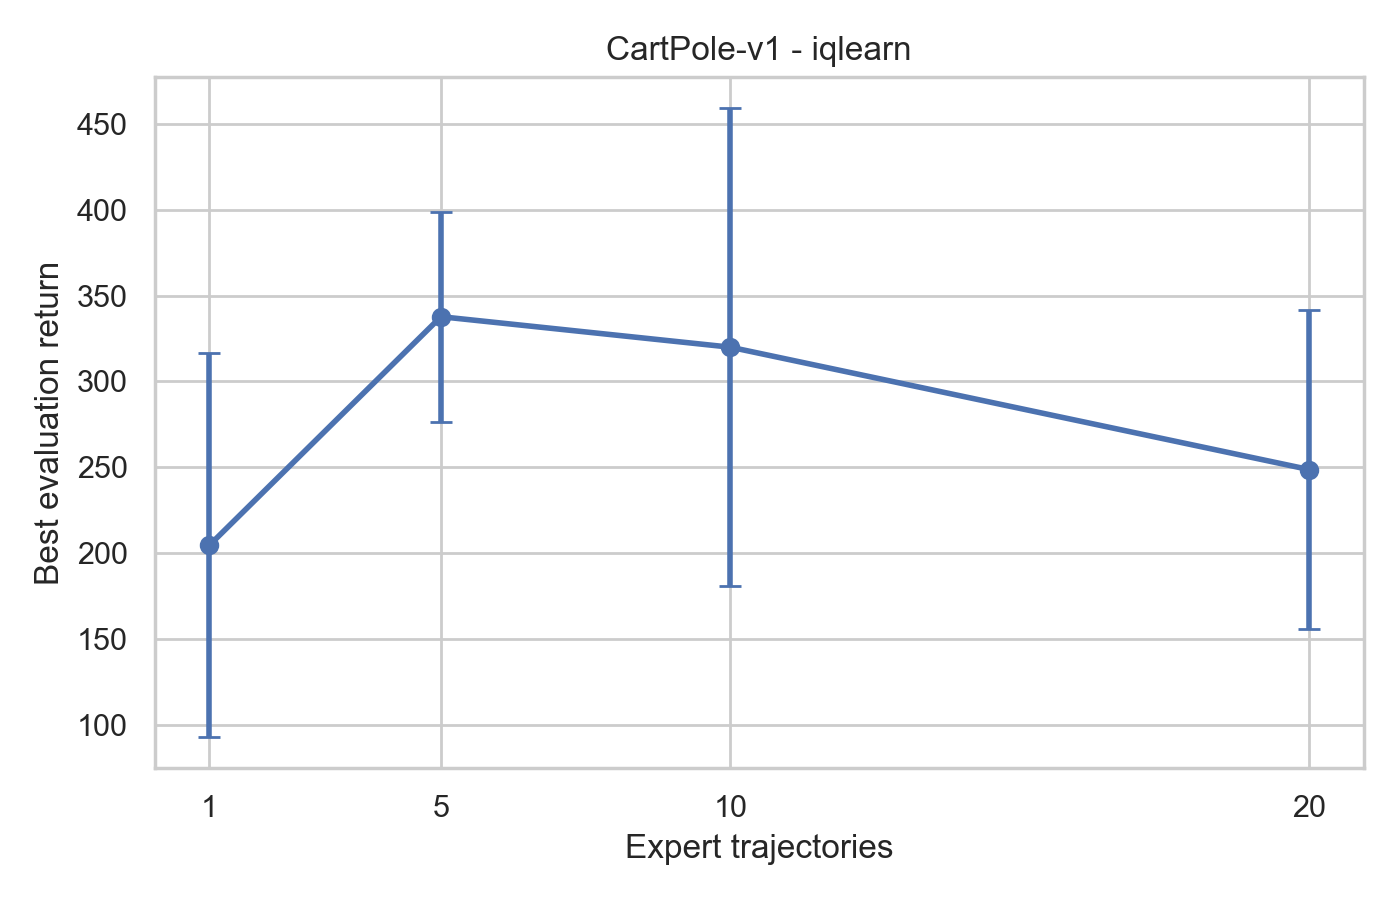

In [9]:
figure_path = PROJECT_ROOT / "results" / "figures" / "CartPole-v1_iqlearn_best_return.png"
display(Image(filename=str(figure_path)))

## 5. Interpretation notes

The expert data is high quality: each `CartPole-v1` trajectory reaches the 500-step time limit and all actions are valid discrete actions. IQ-Learn learns useful behavior from the data, but the current implementation is not fully stable: best checkpoints are often much better than final checkpoints, and performance is not monotonic in the number of expert trajectories.

For reporting, use `best_return_mean` and `best_return_std` from `aggregate_summary.csv`, and mention that the current IQ-Learn implementation saves the best evaluation checkpoint rather than the final training step.